# Fixed-depth analysis: 12D, 15 instances

This notebook compares fixed random-forest depths 5, 10, 15, 20, and 25 on benchmark seed 40. The curves show the mean **best-so-far regret** and a two-sided 95% Student-*t* confidence interval across five SMAC seeds. Lower regret is better. Boxplots show the five seed-level outcomes at every 500 completed trials.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import t

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 50)

RELATIVE_EXPERIMENT = Path('experiments/synthaticBench/o1_deterministic/3500_depth_policies/02_12d_15_instances')
EXPERIMENT = RELATIVE_EXPERIMENT if RELATIVE_EXPERIMENT.exists() else Path.cwd()
OUTPUT = EXPERIMENT / 'smac_output'
BENCHMARK_SEED = 40
DEPTHS = (5, 10, 15, 20, 25)
SMAC_SEEDS = tuple(range(5))
N_TRIALS = 3500
CHECKPOINTS = tuple(range(500, N_TRIALS + 1, 500))
COLORS = dict(zip(DEPTHS, sns.color_palette('viridis', n_colors=len(DEPTHS))))
print('Experiment:', EXPERIMENT.resolve())

Experiment: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/3500_depth_policies/02_12d_15_instances


## Load and validate the trajectories

The notebook reports missing or malformed runs and uses every valid, complete 3,500-trial trajectory it finds. The intended design is five depths by five SMAC seeds.

In [2]:
records = []
problems = []
for depth in DEPTHS:
    for smac_seed in SMAC_SEEDS:
        path = OUTPUT / f'benchmark_seed_{BENCHMARK_SEED}' / f'fixed_depth_{depth}' / str(smac_seed) / 'trajectory.json'
        if not path.exists():
            problems.append({'depth': depth, 'smac_seed': smac_seed, 'problem': 'missing trajectory'})
            continue
        try:
            data = json.loads(path.read_text())
            values = np.asarray(data['best_regret'], dtype=float)
        except (OSError, json.JSONDecodeError, KeyError, TypeError, ValueError) as error:
            problems.append({'depth': depth, 'smac_seed': smac_seed, 'problem': str(error)})
            continue
        failed = []
        if data.get('benchmark_seed') != BENCHMARK_SEED: failed.append('benchmark_seed')
        if data.get('smac_seed') != smac_seed: failed.append('smac_seed')
        if data.get('max_depth') != depth: failed.append('max_depth')
        if len(values) != N_TRIALS: failed.append('trajectory length')
        if not np.isfinite(values).all(): failed.append('non-finite regret')
        if np.any(np.diff(values) > 1e-10): failed.append('not best-so-far monotone')
        if failed:
            problems.append({'depth': depth, 'smac_seed': smac_seed, 'problem': ', '.join(failed)})
            continue
        records.append({'depth': depth, 'smac_seed': smac_seed, 'best_regret': values, 'path': path})

runs = pd.DataFrame(records)
coverage = (runs.groupby('depth').size().reindex(DEPTHS, fill_value=0).rename('valid_runs').to_frame())
coverage['expected_runs'] = len(SMAC_SEEDS)
display(coverage)
if problems:
    display(pd.DataFrame(problems))
if runs.empty:
    raise RuntimeError('No valid trajectories were found.')
print(f'Loaded {len(runs)} / {len(DEPTHS) * len(SMAC_SEEDS)} expected trajectories.')

,valid_runs,expected_runs
depth,,
5,5,5
10,5,5
15,5,5
20,5,5
25,5,5


Loaded 25 / 25 expected trajectories.


In [3]:
iterations = np.arange(1, N_TRIALS + 1)
trajectory_data = pd.DataFrame({
    'depth': np.repeat(runs['depth'].to_numpy(), N_TRIALS),
    'smac_seed': np.repeat(runs['smac_seed'].to_numpy(), N_TRIALS),
    'iteration': np.tile(iterations, len(runs)),
    'best_regret': np.vstack(runs['best_regret'].to_numpy()).ravel(),
})
trajectory_ci = (
    trajectory_data.groupby(['depth', 'iteration'], as_index=False)
    .agg(mean=('best_regret', 'mean'), std=('best_regret', 'std'), n=('best_regret', 'size'))
)
trajectory_ci['ci95'] = t.ppf(0.975, trajectory_ci['n'] - 1) * trajectory_ci['std'] / np.sqrt(trajectory_ci['n'])
positive = trajectory_data.loc[trajectory_data['best_regret'] > 0, 'best_regret']
PLOT_FLOOR = max(float(positive.min()) * 0.5, 1e-12) if len(positive) else 1e-12
print(f'Log-scale floor: {PLOT_FLOOR:.3g}')

Log-scale floor: 1.04e+03


## Best-so-far trajectories with 95% confidence intervals

The shaded bands are uncertainty intervals for the mean across SMAC seeds, not intervals containing 95% of individual runs. The logarithmic y-axis makes differences late in optimization visible.

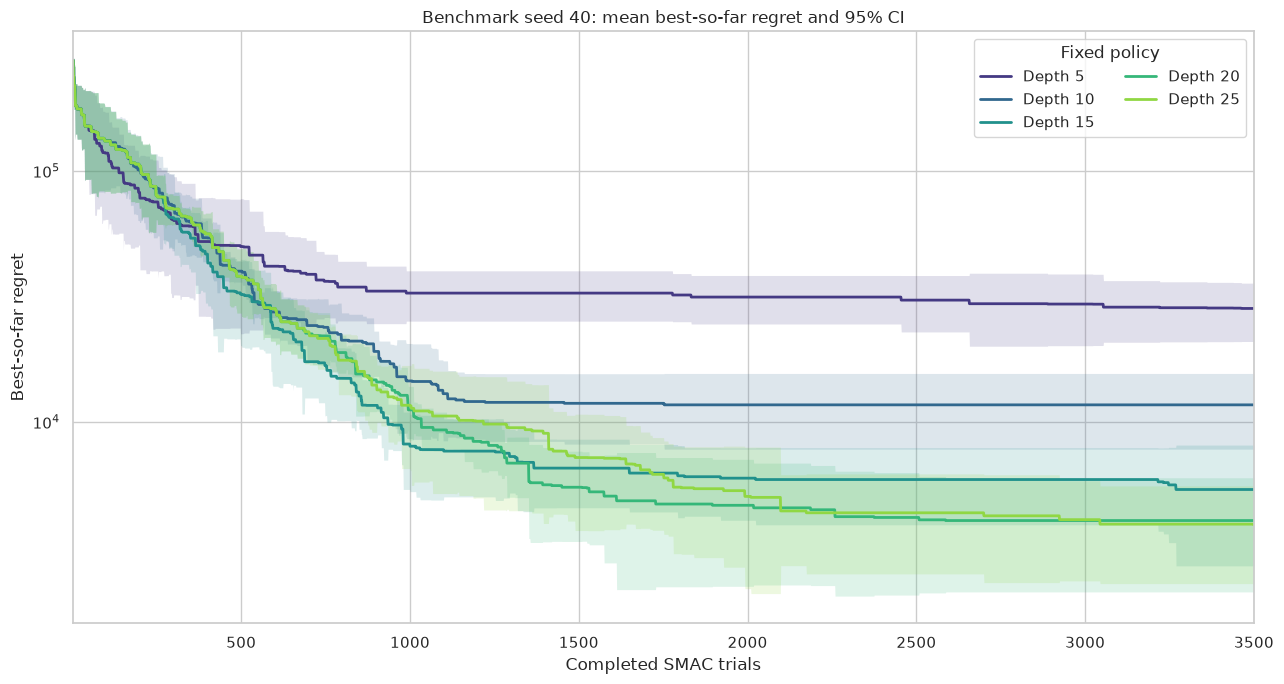

In [4]:
fig, axis = plt.subplots(figsize=(13, 7))
for depth in DEPTHS:
    values = trajectory_ci.query('depth == @depth').sort_values('iteration')
    if values.empty:
        continue
    x = values['iteration'].to_numpy()
    mean = values['mean'].to_numpy()
    half_width = values['ci95'].fillna(0).to_numpy()
    axis.plot(x, np.maximum(mean, PLOT_FLOOR), color=COLORS[depth], lw=2, label=f'Depth {depth}')
    axis.fill_between(x, np.maximum(mean - half_width, PLOT_FLOOR), np.maximum(mean + half_width, PLOT_FLOOR), color=COLORS[depth], alpha=0.16, linewidth=0)
axis.set(yscale='log', xlim=(1, N_TRIALS), xlabel='Completed SMAC trials', ylabel='Best-so-far regret', title=f'Benchmark seed {BENCHMARK_SEED}: mean best-so-far regret and 95% CI')
axis.legend(title='Fixed policy', ncol=2)
fig.tight_layout()
plt.show()

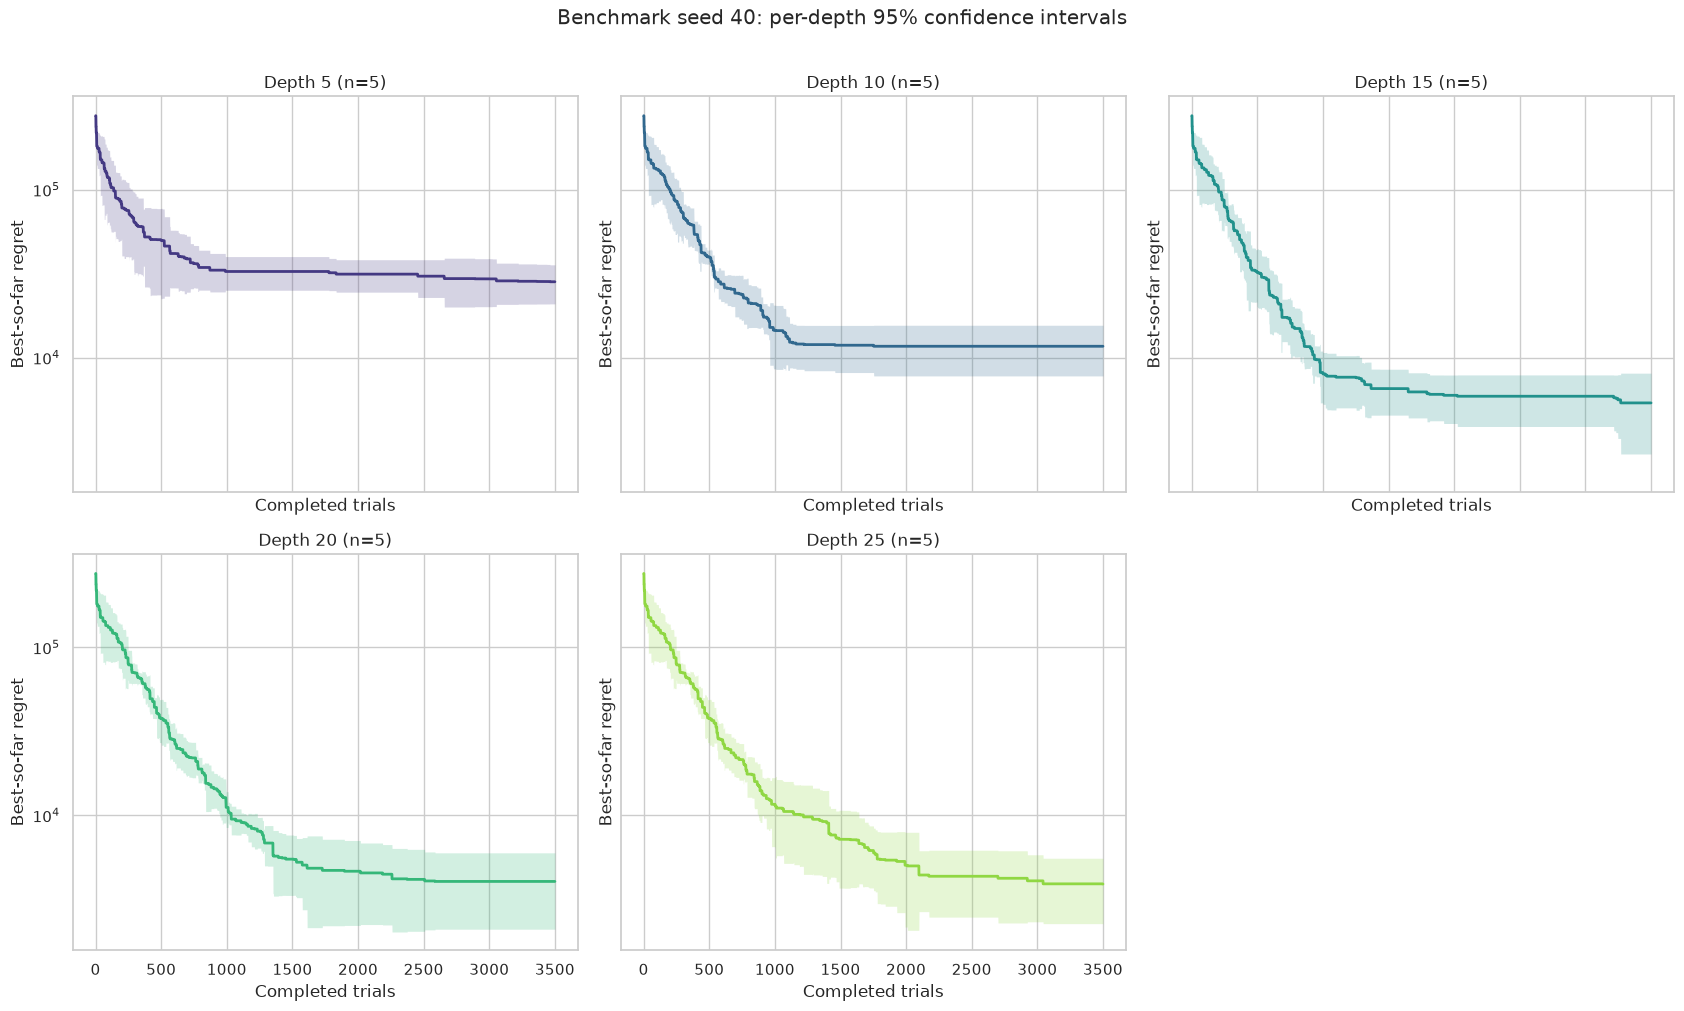

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharex=True, sharey=True)
for axis, depth in zip(axes.ravel(), DEPTHS):
    values = trajectory_ci.query('depth == @depth').sort_values('iteration')
    x = values['iteration'].to_numpy()
    mean = values['mean'].to_numpy()
    half_width = values['ci95'].fillna(0).to_numpy()
    axis.plot(x, np.maximum(mean, PLOT_FLOOR), color=COLORS[depth], lw=2)
    axis.fill_between(x, np.maximum(mean - half_width, PLOT_FLOOR), np.maximum(mean + half_width, PLOT_FLOOR), color=COLORS[depth], alpha=0.22, linewidth=0)
    axis.set_title(f'Depth {depth} (n={int(values.n.max())})')
    axis.set_yscale('log')
    axis.set_xlabel('Completed trials')
    axis.set_ylabel('Best-so-far regret')
axes.ravel()[-1].axis('off')
fig.suptitle(f'Benchmark seed {BENCHMARK_SEED}: per-depth 95% confidence intervals', y=1.01)
fig.tight_layout()
plt.show()

## Best-so-far regret boxplots every 500 trials

Each box contains one value per available SMAC seed. The black points expose all observations, which is important because each policy has only five repetitions.

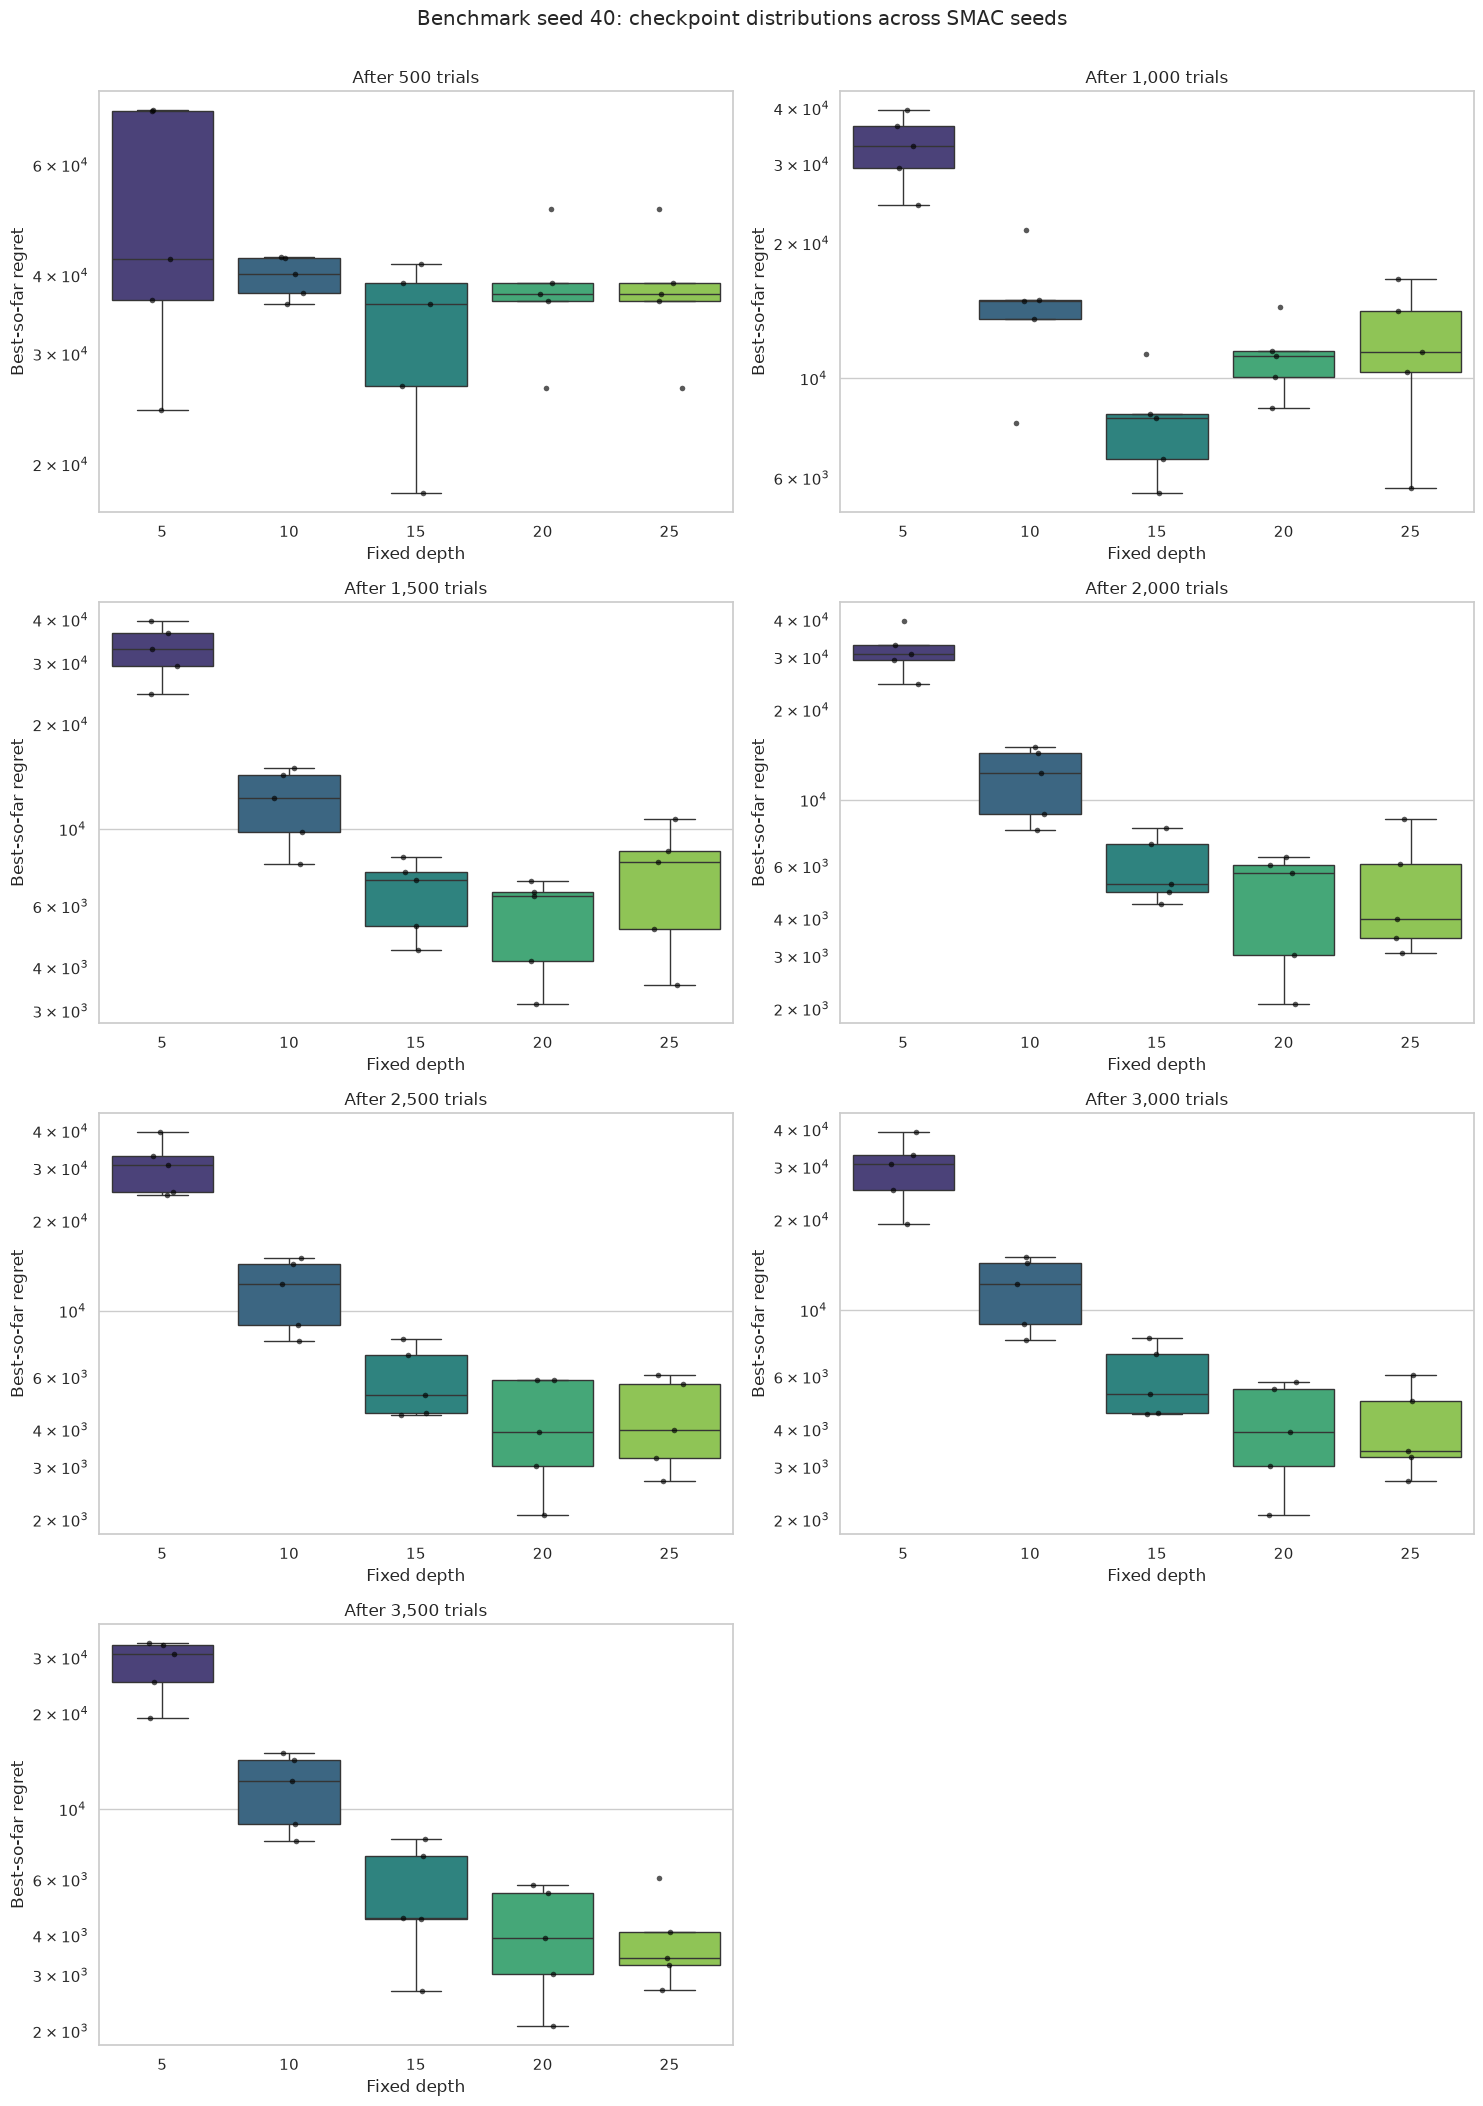

In [6]:
checkpoint_data = trajectory_data[trajectory_data['iteration'].isin(CHECKPOINTS)].copy()
checkpoint_data['plot_regret'] = checkpoint_data['best_regret'].clip(lower=PLOT_FLOOR)
fig, axes = plt.subplots(4, 2, figsize=(15, 21), sharey=False)
for axis, checkpoint in zip(axes.ravel(), CHECKPOINTS):
    values = checkpoint_data.query('iteration == @checkpoint')
    sns.boxplot(data=values, x='depth', y='plot_regret', order=DEPTHS, hue='depth', palette=COLORS, dodge=False, legend=False, showfliers=False, ax=axis)
    sns.stripplot(data=values, x='depth', y='plot_regret', order=DEPTHS, color='black', alpha=0.65, size=4, jitter=0.12, ax=axis)
    axis.set_yscale('log')
    axis.set_title(f'After {checkpoint:,} trials')
    axis.set_xlabel('Fixed depth')
    axis.set_ylabel('Best-so-far regret')
axes.ravel()[-1].axis('off')
fig.suptitle(f'Benchmark seed {BENCHMARK_SEED}: checkpoint distributions across SMAC seeds', y=1.002)
fig.tight_layout()
plt.show()

## Numerical checkpoint summary

This table provides the values behind the plots. Ranking is based on mean best-so-far regret at each checkpoint; lower is better.

In [7]:
checkpoint_summary = (
    checkpoint_data.groupby(['iteration', 'depth'], as_index=False)
    .agg(mean_regret=('best_regret', 'mean'), median_regret=('best_regret', 'median'), std_regret=('best_regret', 'std'), min_regret=('best_regret', 'min'), max_regret=('best_regret', 'max'), n=('best_regret', 'size'))
)
checkpoint_summary['ci95'] = t.ppf(0.975, checkpoint_summary['n'] - 1) * checkpoint_summary['std_regret'] / np.sqrt(checkpoint_summary['n'])
checkpoint_summary['rank'] = checkpoint_summary.groupby('iteration')['mean_regret'].rank(method='min', ascending=True).astype(int)
checkpoint_summary = checkpoint_summary.sort_values(['iteration', 'rank', 'depth'])
display(checkpoint_summary[['iteration', 'rank', 'depth', 'mean_regret', 'ci95', 'median_regret', 'std_regret', 'min_regret', 'max_regret', 'n']].style.format({
    'mean_regret': '{:.6g}', 'ci95': '{:.3g}', 'median_regret': '{:.6g}',
    'std_regret': '{:.3g}', 'min_regret': '{:.6g}', 'max_regret': '{:.6g}',
}))

,iteration,rank,depth,mean_regret,ci95,median_regret,std_regret,min_regret,max_regret,n
2,500,1,15,32279.4,1.22e+04,36047.8,9.79e+03,18018.2,41784.9,5
3,500,2,20,38032.1,1.09e+04,37376.7,8.77e+03,26431.6,51036.4,5
4,500,2,25,38032.1,1.09e+04,37376.7,8.77e+03,26431.6,51036.4,5
1,500,4,10,39866,3.8e+03,40279,3.06e+03,35987.8,42847,5
0,500,5,5,49974.2,2.75e+04,42546.4,2.22e+04,24397.6,73326.2,5
7,1000,1,15,8001.82,2.73e+03,8151.62,2.2e+03,5557.99,11356,5
8,1000,2,20,11163.5,2.69e+03,11229,2.17e+03,8572.3,14434.4,5
9,1000,3,25,11651,5.13e+03,11445.2,4.13e+03,5690.42,16625.8,5
6,1000,4,10,14559.3,5.98e+03,14883.1,4.81e+03,7939.99,21453,5
5,1000,5,5,32598.3,7.39e+03,33028,5.95e+03,24397.6,39577.7,5
